# Exploratory Data Analysis of the OGBN-ARXIV Dataset

This notebook provides a simple EDA of the `ogbn-arxiv` dataset from the Open Graph Benchmark (OGB).

In [13]:
import networkx as nx
import seaborn as sns
import torch
from ogb.nodeproppred import NodePropPredDataset
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import warnings
from src.util import cs_map
import pandas as pd

warnings.filterwarnings("ignore", message=".*weights_only=False.*")

## Load Dataset

In [2]:
_original_torch_load = torch.load

def patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

# Apply patch
torch.load = patched_torch_load

# Load dataset
dataset = NodePropPredDataset(name="ogbn-arxiv", root="../../data/ogbn")
graph, labels = dataset[0]

# Restore original (optional)
torch.load = _original_torch_load

# OGBN-ArXiv Dataset: Exploratory Data Analysis

## Dataset Overview

The OGBN-ArXiv dataset is a directed graph representing the citation network between Computer Science (CS) arXiv papers indexed by MAG, where each node is an arXiv paper and each directed edge indicates that one paper cites another. This dataset is part of the Open Graph Benchmark (OGB) suite designed for realistic and challenging graph machine learning tasks.

## Dataset Specifications

| Property | Value | Description |
|----------|--------|-------------|
| **Dataset Name** | `ogbn-arxiv` | Official OGB identifier |
| **Task Type** | Multiclass classification | 40-class prediction problem |
| **Number of Classes** | 40 | CS arXiv subject categories (cs.AI, cs.LG, etc.) |
| **Evaluation Metric** | Accuracy | Standard classification metric |
| **Split Method** | Time-based | Train ≤2017, Valid 2018, Test ≥2019 |
| **Graph Type** | Directed, Homogeneous | Citation relationships preserved |
| **Node Features** | 128-dimensional | Word embeddings averaged from paper titles and abstracts using skip-gram model [4] |
| **Edge Features** | None | No additional edge metadata |
| **Additional Files** | `node_year` | Publication year for temporal analysis |

## Graph Structure

- **Total Nodes**: 169,343 CS papers
- **Directed Edges**: ~1.16M citation relationships
- **Feature Dimension**: 128 per node
- **Time Span**: Multi-year coverage (temporal split available)

## Target Classes

- **AI** → Artificial Intelligence
- **AR** → Hardware Architecture
- **CC** → Computational Complexity
- **CE** → Computational Engineering, Finance, and Science
- **CG** → Computational Geometry
- **CL** → Computation and Language
- **CR** → Cryptography and Security
- **CV** → Computer Vision and Pattern Recognition
- **CY** → Computers and Society
- **DB** → Databases
- **DC** → Distributed, Parallel, and Cluster Computing
- **DL** → Digital Libraries
- **DM** → Discrete Mathematics
- **DS** → Data Structures and Algorithms
- **ET** → Emerging Technologies
- **FL** → Formal Languages and Automata Theory
- **GL** → General Literature
- **GR** → Graphics
- **GT** → Computer Science and Game Theory
- **HC** → Human-Computer Interaction
- **IR** → Information Retrieval
- **IT** → Information Theory
- **LG** → Machine Learning
- **LO** → Logic in Computer Science
- **MA** → Multiagent Systems
- **MM** → Multimedia
- **MS** → Mathematical Software
- **NA** → Numerical Analysis
- **NE** → Neural and Evolutionary Computing
- **NI** → Networking and Internet Architecture
- **OH** → Other Computer Science
- **OS** → Operating Systems
- **PF** → Performance
- **PL** → Programming Languages
- **RO** → Robotics
- **SC** → Symbolic Computation
- **SD** → Sound
- **SE** → Software Engineering
- **SI** → Social and Information Networks
- **SY** → Systems and Control




## References

[1] Open Graph Benchmark. OGBN-ArXiv Dataset. Retrieved from https://ogb.stanford.edu/docs/nodeprop/#ogbn-

[2] arXiv.org. (n.d.). arXiv Category Taxonomy. Retrieved from https://arxiv.org/category_taxonomy



## Extracting the component datasets from the graph
- Node Feat: Numpy ndarray of shape (num_nodes, nodefeat_dim), where nodefeat_dim is the dimensionality of node features and i-th row represents the feature of i-th node. This can be None if no input node features are available

- Edge Feat: Numpy ndarray of shape (num_edges, edgefeat_dim), where edgefeat_dim is the dimensionality of edge features and i-th row represents the feature of i-th edge. This can be None if no input edge features are available.

- Edge Index: Numpy ndarray of shape (2, num_edges), where each column represents an edge. The first row and the second row represent the indices of source and target nodes. Undirected edges are represented by bidirectional edges.

- Number of Nodes: Number of nodes in the graph

- Node Year: Year paper was published

In [3]:
rnode_feat = pd.DataFrame(data=graph['node_feat'])
edge_feat = pd.DataFrame(data=graph['edge_feat'])
edge_index = pd.DataFrame(data=graph['edge_index'])
n = graph['num_nodes']
node_year = pd.DataFrame(data=graph['node_year'])

## Label
### Mapping Label Id to Category & Description
This code creates a label mapping for the arXiv computer science dataset. This mapping helps for understanding what each class represents in the distribution shown in the chart.

In [4]:
mapping = pd.read_csv('../data/ogbn/ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz')

mapping["category"] = mapping["arxiv category"].str.replace("arxiv cs ", "", regex=False).str.lower()
mapping.drop("arxiv category", axis=1, inplace=True)
mapping.rename(columns={'label idx': 'label'}, inplace=True)

labels = pd.DataFrame(data=labels, columns=['label'])

desc = pd.DataFrame(list(cs_map.items()), columns=['category', 'description'])
desc['category'] = desc['category'].str.lower()

labels = pd.merge(labels, mapping, on='label')
labels = pd.merge(labels, desc, on='category')

labels.head()

,label,category,description
0,4,cr,Cryptography and Security
1,5,dc,"Distributed, Parallel, and Cluster Computing"
2,28,it,Information Theory
3,8,ni,Networking and Internet Architecture
4,27,ro,Robotics


### Target Distribution (Insight)

#### Dominant Fields
The distribution is heavily concentrated in a few key areas:
- Computer Vision and Pattern Recognition (CV) - 27,000 papers (highest)
- Machine Learning (LG) - 22,000 papers
- Artificial Intelligence (AI) - 21,000 papers

#### Secondary Clusters
Several fields show moderate activity (5,000-12,000 papers):
- Computation and Language (CL)
- Cryptography and Security (CR)
- Robotics (RO)
- Data Structures and Algorithms (DS)

#### Long Tail Distribution
Most computer science subfields have modest paper counts (under 5,000):
- Hardware Architecture (AR)
- Databases (DB)
- Human-Computer Interaction (HC)
- Software Engineering (SE)
- Computational Complexity (CC)
- Formal Languages (FL)

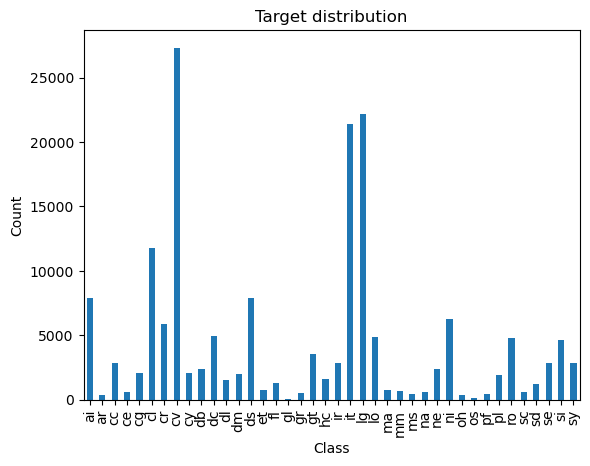

In [5]:
labels['category'].value_counts().sort_index().plot(kind='bar')
plt.title("Target distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#### Class Imbalance
Machine learning models tend to favor classes with more examples. The target distribution shows three dominant categories — **Computer Vision and Pattern Recognition**, **Machine Learning (LG)**, and **Artificial Intelligence (AI)** — each with substantially more samples than the rest. Most other classes have around 12–13k examples or fewer. This imbalance means the model will likely overfit to dominant classes and underperform on minority ones, so **Macro-F1** will be used to better assess performance across all classes.



## Node Feature

Node Feat contains 169,343 examples and 128 features already converted into text embeddings. Node features in OGBN-ArXiv consist of 128-dimensional vectors representing the semantic content of each paper's title and abstract, created by averaging pre-trained skip-gram word embeddings trained on the Microsoft Academic Graph corpus [1].

In [6]:
print(f'The node feature dataset contains {node_feat.shape[0]} examples and {node_feat.shape[1]} features.')

The node feature dataset contains 169343 examples and 128 features.


In [7]:
print(f'The node feature contains {node_feat.isna().sum().sum()} missing entries')

The node feature contains 0 missing entries


In [8]:
node_feat.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-0.057943,-0.052530,-0.072603,-0.026555,0.130435,-0.241386,-0.449242,-0.018443,-0.087218,0.112320,...,0.211490,-0.226118,-0.185603,0.053230,0.332873,0.104175,0.007408,0.173364,-0.172796,-0.140059
1,-0.124500,-0.070665,-0.325202,0.007779,-0.001559,0.074189,-0.191013,0.049689,0.026369,0.099364,...,0.106316,0.052926,-0.258378,0.021567,0.281503,-0.173423,0.202082,0.068524,-0.372111,-0.301036
2,-0.080242,-0.023328,-0.183787,-0.180707,0.075765,-0.125818,-0.394573,-0.219078,-0.108931,0.056966,...,0.019453,-0.070291,-0.177562,-0.214012,0.182186,-0.121589,-0.073642,0.109919,0.117589,-0.139883
3,-0.145044,0.054915,-0.126666,0.039971,-0.055909,-0.101278,-0.339202,-0.115801,-0.080058,-0.001633,...,-0.065752,0.042735,0.066338,-0.226921,0.188418,-0.017295,0.063449,0.017816,0.085364,-0.081804
4,-0.071154,0.070766,-0.281432,-0.161892,-0.165246,-0.029116,-0.338593,-0.138727,0.100015,0.132794,...,-0.056130,0.047475,-0.263795,0.026462,0.376349,-0.253772,0.084472,0.098033,-0.075347,-0.111687


### Visualization of Node Feature Dataset
#### T-Distributed Stochastic Neighbor Embedding (Insight)
t-SNE is a nonlinear dimensionality reduction algorithm that’s especially popular for visualizing high-dimensional data in 2D. It projects the 128-dimensional node features into two dimensions, preserving local similarities among papers.
Nearby points represent papers with similar feature patterns, while global distances are less meaningful.

- Central dense region: most papers cluster here, showing a strong overlap among related fields such as ML, AI, and NLP.
- Upper-right gradient: slightly higher concentration of Computer Vision and Pattern Recognition papers.
- Lower-left edge: sparser, more distinct points — likely smaller or specialized subfields.

Overall: the distribution is continuous rather than clearly segmented, suggesting that while node features capture topical relationships, many research areas remain closely intertwined in the feature space.

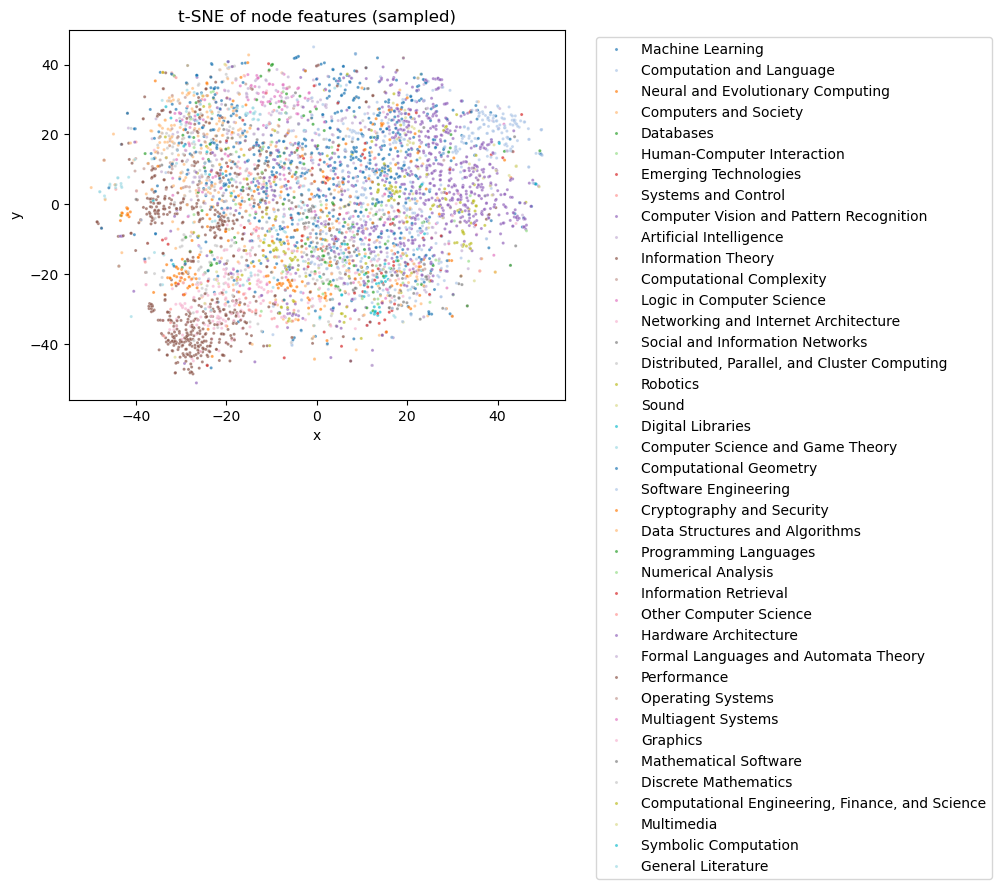

In [23]:
# Settings
seed = 42
perplexity = 30
size = 5000
num_exs = node_feat.shape[0]
n_components = 2

# Randomly select a number of examples defined by size out of num_exs. This gives us an array of random indices.
# Use the random indices to extract the examples from the X and y
np.random.seed(seed)
idxs = np.random.choice(num_exs, size=size, replace=False)
ft_sampled = node_feat.iloc[idxs,:]
lb_sampled = labels.iloc[idxs,:]

# TSNE: fit transform will compress the 128 dimensions from the original
# dataset to the number of dimensions define by n_components
tsne = TSNE(n_components=n_components, random_state=seed, perplexity=perplexity)
ft_embedded = tsne.fit_transform(ft_sampled)

sns.scatterplot(
    data=pd.DataFrame({'x': ft_embedded[:,0], 'y': ft_embedded[:,1], 'label': lb_sampled['description'].values}),
    x='x',
    y='y',
    hue='label',
    palette='tab20',
    s=5,
    alpha=0.7,
    legend='full'
)
plt.title("t-SNE of node features (sampled)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Edge Feature
Empty (Not Used)

In [10]:
print(f'The edge index dataset contains {edge_feat.shape[0]} examples and {edge_feat.shape[1]} features.')

The edge index dataset contains 0 examples and 0 features.


## Edge Index
Edge Index contains the citation relationships between any two nodes/papers. The graph structure captures academic citation relationships through directed edges, where an edge from node A to node B indicates that paper A cites paper B [1].

### Basic Stats
- The number of nodes and edges describes the structure and total number of papers and citations we are analyzing
- The average degree measures how many citations each paper has, on average. The average paper contains about 13 to 14 citations. The average degree can tell us can give insight into the activity level.
- The density compares how many actual citations exist versus the maximum possible. The Eq 2E/N(N-1) calculates what fraction of possible connections is present. The Edge Index with a 0.00004 density suggests a sparse network likely due to the fact the papers only cite earlier work.

The low density combined with a decent average degree suggests a typical academic citation pattern - papers are selective about what they cite, but the ones that do get cited tend to accumulate multiple citations over time.

In [11]:
G = nx.DiGraph()
G.add_edges_from(edge_index.T.to_numpy())
numb_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
average_degree = sum(dict(G.degree()).values()) / numb_nodes
density = nx.density(G)
isolated_nodes = list(nx.isolates(G))

print(f'The edge index dataset contains {num_edges} edges and {numb_nodes} nodes.')
print(f'The average degree of the baselines is {average_degree:.2f}.')
print(f'The density of the baselines is {density}.')
print(f'The number of isolated nodes in the baselines are {len(set(isolated_nodes))}.')

The edge index dataset contains 1166243 edges and 169343 nodes.
The average degree of the graph is 13.77.
The density of the graph is 4.066840277668502e-05.
The number of isolated nodes in the graph are 0.


In [12]:
edge_index.head()

,0,1,2,3,4,5,6,7,8,9,...,1166233,1166234,1166235,1166236,1166237,1166238,1166239,1166240,1166241,1166242
0,104447,15858,107156,107156,107156,107156,141536,141536,141536,141536,...,45118,45118,45118,45118,45118,45118,45118,45118,45118,45118
1,13091,47283,69161,136440,107366,158460,90124,121740,122427,161023,...,144525,49499,29457,144665,135414,79124,147994,162473,162537,72717


## Conclusion

The dataset’s distribution is heavily concentrated in a few dominant research areas — Computer Vision and Pattern Recognition (≈27k papers), Machine Learning (≈22k), and Artificial Intelligence (≈21k). Models trained on this data are likely to favor these majority classes and underperform on minority ones. Metrics such as F1 and Macro-F1, which combine precision and recall
\\[
F1 = \frac{2PR}{P + R}
\\]
are better suited for evaluating such imbalanced datasets since they treat all classes equally.

The 2-D t-SNE map shows that nodes feature embedding cluster locally but overlap substantially across categories. This indicates that related topics share similar representations and that the feature space forms a continuous manifold with only subtle regional density differences rather than distinct boundaries.

The graph structure consists of 169,343 nodes (papers) and 1,166,243 directed edges (citations). Each paper cites or is cited by roughly 13 others on average, while the overall density (≈ 4.07 × 10⁻⁵) confirms an extremely sparse network. Such sparsity reflects a typical citation pattern—selective referencing with a few highly connected hub papers.

Overall, the dataset captures meaningful topical structure but exhibits strong class imbalance and overlapping features, both of which are likely to affect downstream model performance and generalization.
